# MLP Experiments

This notebook implements our Multilayered Perceptron, including everything needed to set up the data it needs and run the experiments for figuring out what MLP architecture is best at classifying a disease based off of some embedding of symptoms.

In [13]:
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import copy
import random

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.metrics import precision_score
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset

import time

# Ensure deterministic behavior for reproducibility
SEED = 0
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [14]:
# Data loading and split
DATA_PATH = Path("data.csv")
if not DATA_PATH.exists():
    raise FileNotFoundError(f"Could not find dataset at {DATA_PATH.resolve()}")

# First row of the CSV, which contains the column names.
header_only = pd.read_csv(DATA_PATH, nrows=0)

# All the column names in the dataset, which are the symptoms and the target disease column.
all_columns = header_only.columns.tolist()
target_col = "diseases"

# Every column that isn't the disease label is a symptom feature.
symptom_cols = [c for c in all_columns if c != target_col]

# We treat each symptom column as a binary feature (0 or 1), so we can load them as uint8 to save memory.
# Either a patient has the symptom or they don't (see exploration notebook for more details on the dataset).
dtype_map = {c: "uint8" for c in symptom_cols}
df = pd.read_csv(DATA_PATH, dtype=dtype_map)

# Construct our feature matrix X holding the symptom data as floats (0.0 or 1.0).
X = df[symptom_cols].to_numpy(dtype=np.float32)

# The disease labels are categorical strings, so we convert them to integer codes for training.
y_cat = df[target_col].astype("category")

# Stratified splitting requires at least 2 samples per class, so we drop classes that appear only once.
class_counts = y_cat.value_counts()
valid_classes = class_counts[class_counts >= 2].index
valid_mask = y_cat.isin(valid_classes)

X = X[valid_mask.to_numpy()]
y_cat = y_cat[valid_mask].astype("category")

# The .cat.codes attribute gives us the integer codes for each category, 
# and .cat.categories gives us the mapping from codes to original category names.
y = y_cat.cat.codes.to_numpy(dtype=np.int64)

# We'll need the mapping from integer codes back to disease names later for evaluation and interpretation, so we save it here.
classes = y_cat.cat.categories.tolist()

# A little arbitrary, but these are what portions of the data we hold out for testing and validation. 
# The rest is used for training.
TEST_SIZE = 0.15
VAL_SIZE = 0.15

# This tears up X and y into two splits: trainval and test. 
# The test set is held out until the very end for final evaluation, while the trainval set 
# is used for both training and validation 
# (we'll split it again into train and val in the next step).
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=SEED,
    stratify=y,
)

# And here we do just that: split the trainval set into separate train and val sets.
# Since we split off the test set first, we need to adjust the validation size to
# still be the intended portion of the original full dataset, not just the remaining trainval set.
# (so without this line it would be like 15% of 85% of the original data)
val_share_of_trainval = VAL_SIZE / (1.0 - TEST_SIZE)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval,
    y_trainval,
    test_size=val_share_of_trainval,
    random_state=SEED,
    stratify=y_trainval,
)

print(f"Train shape: {X_train.shape}")
print(f"Val shape:   {X_val.shape}")
print(f"Test shape:  {X_test.shape}")
print(f"Num classes: {len(classes)}")

Train shape: (172848, 377)
Val shape:   (37039, 377)
Test shape:  (37039, 377)
Num classes: 773


In [15]:
class SymptomDataset(Dataset):
    """
    Helper class I made to wrap our symptom data in a PyTorch Dataset
    so that we can easily load it in batches for training and evaluation.
    Implements the standard Dataset interface with __len__ and __getitem__ methods,
    and converts the input numpy arrays to PyTorch tensors.
    """
    def __init__(self, features: np.ndarray, labels: np.ndarray) -> None:
        """
        Initializes the dataset with the given features and labels, converting them from numpy arrays to PyTorch tensors.

        @param features: A numpy array of shape (num_samples, num_features) containing the symptom data.
        @param labels: A numpy array of shape (num_samples,) containing the integer-encoded
                       disease labels corresponding to each sample in the features array.
        """
        self.features = torch.from_numpy(features)
        self.labels = torch.from_numpy(labels)

    def __len__(self) -> int:
        """
        Returns the number of samples in the dataset, which is determined by the length of the labels tensor.

        @return: The number of samples in the dataset.
        """
        return len(self.labels)

    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        Retrieves the feature and label tensors for the sample at the specified index.

        @param idx: The index of the sample to retrieve.
        @return: A tuple containing the feature tensor and the label tensor for the specified index.
        """
        return self.features[idx], self.labels[idx]


# Helper function to build a DataLoader from our features and labels numpy arrays, 
# using the SymptomDataset class we just defined.
# We do this for each of our train, val, and test splits to get DataLoaders we can iterate over 
# in batches during training and evaluation.
def build_loader(
    features: np.ndarray,
    labels: np.ndarray,
    batch_size: int,
    shuffle: bool,
) -> DataLoader:
    """
    Builds a PyTorch DataLoader from the given features and labels numpy arrays, using the SymptomDataset class.
    
    @param features: A numpy array of shape (num_samples, num_features) containing the symptom data.
    @param labels: A numpy array of shape (num_samples,) containing the integer-encoded
                   disease labels corresponding to each sample in the features array.
    @param batch_size: The number of samples to load and process together in one forward/backward pass during training and evaluation.
    @param shuffle: Whether to shuffle the data at the start of each epoch.
    @return: A PyTorch DataLoader that can be iterated over to yield batches of (features, labels) tensors.
    """
    dataset = SymptomDataset(features, labels)

    # num_workers=0 means the data loading will happen in the main process.
    # pin_memory=True means that the DataLoader will copy tensors into CUDA pinned memory before returning them, 
    # which can speed up data transfer to the GPU if we're using one.
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle, num_workers=0, pin_memory=torch.cuda.is_available())

# I picked a batch size of 1024 somewhat arbitrarily.
# This controls how many samples we load and process together in one forward/backward pass during training and evaluation.
BATCH_SIZE = 1024
train_loader = build_loader(X_train, y_train, batch_size=BATCH_SIZE, shuffle=True)
val_loader = build_loader(X_val, y_val, batch_size=BATCH_SIZE, shuffle=False)
test_loader = build_loader(X_test, y_test, batch_size=BATCH_SIZE, shuffle=False)

In [16]:
class SymptomMLP(nn.Module):
    """
    To implement our MLP model, we define a class that inherits from nn.Module.
    This way, we can easily define the layers of our network in the __init__ method 
    and the forward pass in the forward method.
    Otherwise, without this class we'd have to do something like
    ```
    mlp = nn.Sequential(
        nn.Linear(input_dim, hidden_dim1),
        nn.ReLU(),
        ...
        nn.Linear(hidden_dimN, output_dim)
    )
    ```
    for every model we want to try, which I was gonna do (and started to do) but then realized was much more annoying to experiment with.
    """
    def __init__(
        self,
        input_dim: int,
        output_dim: int,
        hidden_dims: List[int],
        dropout: float = 0.0,
        embedding_dim: Optional[int] = None,
        batch_norm: bool = False,
        input_dropout: float = 0.0,
    ) -> None:
        """
        Initializes the MLP model with the specified architecture parameters.
        We use ReLU for everything, so if we want to try a different activation function we would have to change the code here.

        @param input_dim: The number of input features (symptoms).
        @param output_dim: The number of output classes (diseases).
        @param hidden_dims: A list of integers specifying the number of units in each hidden layer of the MLP.
        @param dropout: The dropout rate to apply after each hidden layer (0.0 means no dropout).
        @param embedding_dim: If specified, the number of units in an optional learnable embedding layer that 
                              projects the input features before the hidden layers.
        @param batch_norm: If True, applies BatchNorm1d after each linear layer and before ReLU to stabilize training.
        @param input_dropout: Dropout applied directly to the input symptom vector before any learned projection.
        """
        # Call the superclass constructor to properly initialize the nn.Module.
        super().__init__()

        # Will hold all the layers of our network in order, 
        # which we will then wrap in an nn.Sequential for the forward pass.
        layers: List[nn.Module] = []

        # Used to track the output dimension of the previous layer so we can connect it to the next layer.
        prev_dim = input_dim

        # Input-level dropout is a regularizer that randomly masks symptom features before any learned transformation.
        # This can reduce over-reliance on any single symptom feature and improve generalization.
        if input_dropout > 0:
            layers.append(nn.Dropout(input_dropout))

        # If we are using an embedding layer, add it as the first layer of the network, 
        # projecting from input_dim to embedding_dim.
        if embedding_dim is not None:
            layers.append(nn.Linear(prev_dim, embedding_dim))

            # Batch norm is optional and applied before ReLU to normalize the hidden representation.
            if batch_norm:
                layers.append(nn.BatchNorm1d(embedding_dim))

            layers.append(nn.ReLU())

            # I think the embedding layer is still a hidden layer, so we apply dropout after it if specified.
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            prev_dim = embedding_dim

        # For every hidden dimension specified in the hidden_dims list, 
        # add a linear layer followed by a ReLU activation (and optional batch norm + dropout regularization).
        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, hidden_dim))

            # Batch normalization can make optimization smoother and can also act as a mild regularizer.
            if batch_norm:
                layers.append(nn.BatchNorm1d(hidden_dim))

            layers.append(nn.ReLU())

            # Dropout regularization after each hidden activation.
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            prev_dim = hidden_dim

        # Finally, add the output layer that projects from the last hidden dimension to the output dimension (number of classes).
        layers.append(nn.Linear(prev_dim, output_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Defines the forward pass of the MLP model, 
        which simply applies the sequentially defined layers to the input tensor x.

        @param x: A tensor of shape (batch_size, input_dim) containing the input features for a batch of samples.
        @return: A tensor of shape (batch_size, output_dim) containing the raw output scores (logits) for each class.
        """
        return self.net(x)

In [17]:
# I recently learned that if you add @dataclass to a class definition, 
# it automatically generates __init__, __repr__, and __eq__, based on the class attributes you define.
@dataclass
class ExperimentConfig:
    """
    Represents the configuration for a training experiment, including model architecture and training hyperparameters.
    Makes it really easy to just define a config object with all the parameters we want to specify for an experiment,
    and then we can easily print it out to keep track of what settings we used for each experiment.
    """
    name: str
    hidden_dims: List[int]
    dropout: float
    embedding_dim: Optional[int]
    lr: float
    batch_size: int
    max_epochs: int
    num_epochs_till_early_stop: int
    batch_norm: bool = False
    input_dropout: float = 0.0
    weight_decay: float = 0.0
    l1_lambda: float = 0.0
    label_smoothing: float = 0.0


def accuracy_from_logits(logits: torch.Tensor, y_true: torch.Tensor) -> float:
    """
    Takes the raw output scores (logits) from the model and the true labels,
    and computes the accuracy by comparing the predicted class (the one with the highest logit) to the true labels.

    @param logits: A tensor of shape (batch_size, num_classes) containing the raw output scores from the model for each class.
    @param y_true: A tensor of shape (batch_size,) containing the true integer-encoded class labels for each sample in the batch.
    @return: The accuracy as a float between 0.0 and 1.0, representing the proportion of correct predictions in the batch.
    """
    preds = torch.argmax(logits, dim=1)
    return (preds == y_true).float().mean().item()


def evaluate_model(model: nn.Module, loader: DataLoader) -> Dict[str, float]:
    """
    Evaluates the given model on the data provided by the loader, 
    computing the average loss, accuracy, and macro-averaged precision across all batches 
    (macro as in averaging the precision for each class without weighting by support, 
    so it treats all classes equally regardless of how many samples they have).

    @param model: The MLP model to evaluate.
    @param loader: A DataLoader providing batches of (features, labels) to evaluate the model on.
    @return: A dictionary containing the average loss, accuracy, and macro-averaged precision of the model on the provided data.
    The loss is averaged across all batches, the accuracy is averaged across all batches, 
    and the macro-averaged precision is computed across all predictions and true labels from all batches.
    """
    # Set the model to evaluation mode, which turns off dropout and other training-specific behavior.
    model.eval()
    total_loss = 0.0
    total_acc = 0.0
    n_batches = 0

    all_preds: List[np.ndarray] = []
    all_targets: List[np.ndarray] = []

    # We use CrossEntropyLoss for multi-class classification.
    # We could try experimenting with different loss functions.
    criterion = nn.CrossEntropyLoss()

    with torch.no_grad():
        # Iterate over the batches of data provided by the loader, 
        # moving the input features and labels to the appropriate device (CPU or GPU).
        for xb, yb in loader:
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)

            # Compute the model's output logits for the batch, and then compute the loss using the criterion.
            logits = model(xb)
            loss = criterion(logits, yb)

            # Accumulate the total loss and accuracy across batches, 
            # and keep track of all predictions and true labels for precision calculation.
            total_loss += loss.item()
            total_acc += accuracy_from_logits(logits, yb)
            n_batches += 1

            # Get the predicted class for each sample in the batch by taking the argmax of the logits,
            # and store the predictions and true labels for later precision calculation.
            preds = torch.argmax(logits, dim=1)
            all_preds.append(preds.cpu().numpy())
            all_targets.append(yb.cpu().numpy())

    # After iterating through all batches, we concatenate all the predictions and true labels into single arrays,
    # and compute the macro-averaged precision across all samples.
    y_pred = np.concatenate(all_preds)
    y_true = np.concatenate(all_targets)

    macro_precision = precision_score(y_true, y_pred, average="macro", zero_division=0)

    # Build the output dictionary.
    return {
        "loss": total_loss / max(1, n_batches),
        "accuracy": total_acc / max(1, n_batches),
        "macro_precision": macro_precision,
    }

In [18]:
def train_one_experiment(
    config: ExperimentConfig,
    X_train_np: np.ndarray,
    y_train_np: np.ndarray,
    X_val_np: np.ndarray,
    y_val_np: np.ndarray,
) -> Dict[str, object]:
    """
    Trains an MLP model according to the specified configuration and training data,
    evaluating on the validation data at the end of each epoch and keeping track of the best model

    @param config: An ExperimentConfig object containing the model architecture and training hyperparameters for this experiment.
    @param X_train_np: A numpy array of shape (num_train_samples, num_features) containing the training features.
    @param y_train_np: A numpy array of shape (num_train_samples,) containing the integer-encoded training labels.
    @param X_val_np: A numpy array of shape (num_val_samples, num_features) containing the validation features.
    @param y_val_np: A numpy array of shape (num_val_samples,) containing the integer-encoded validation labels.
    @return: A dictionary containing the trained model, the training history, and the best epoch's metrics. 
    The history is a list of dictionaries, one per epoch, containing the training and validation loss, accuracy, and macro precision for that epoch. 
    The best epoch is the one with the highest validation accuracy.
    """

    # First, we build DataLoaders for the training and validation data using the build_loader helper function we defined earlier.
    train_loader_local = build_loader(X_train_np, y_train_np, batch_size=config.batch_size, shuffle=True)
    val_loader_local = build_loader(X_val_np, y_val_np, batch_size=config.batch_size, shuffle=False)

    # Next, we take the model architecture parameters from the config and use them to initialize a SymptomMLP model instance,
    # which we then move to the appropriate device (CPU or GPU).
    model = SymptomMLP(
        input_dim=X_train_np.shape[1],
        output_dim=len(classes),
        hidden_dims=config.hidden_dims,
        dropout=config.dropout,
        embedding_dim=config.embedding_dim,
        batch_norm=config.batch_norm,
        input_dropout=config.input_dropout,
    ).to(device)

    # We use an Adam optimizer for training for now since it seems like a good choice from what I've seen in class.
    # But we should definitely look into trying different optimizers and maybe different loss functions as I mentioned earlier.
    # Weight decay here is L2 regularization applied by the optimizer during parameter updates.
    optimizer = torch.optim.Adam(model.parameters(), lr=config.lr, weight_decay=config.weight_decay)

    # Label smoothing regularization can reduce overconfidence by spreading a little probability mass
    # away from the one-hot target class during training.
    criterion = nn.CrossEntropyLoss(label_smoothing=config.label_smoothing)

    # Tracks the training history across epochs, which we will return at the end. 
    # Each entry in the list is a dictionary containing the metrics for one epoch.
    history: List[Dict[str, float]] = []

    # Tracks the best validation accuracy seen so far, the model state corresponding to that best validation accuracy,
    # and how many epochs we've gone without improvement in validation accuracy (for early stopping).
    # -1.0 used as initial value so I know if the model has improved at all since the start of training for debugging, since accuracy is always between 0 and 1.
    best_val_acc = -1.0

    # Tracks the model state (the parameters) corresponding to the best validation accuracy seen so far,
    # which we will restore at the end of training so that the final model we return is the best one we saw during training according to validation accuracy, 
    # rather than the last one we trained.
    best_state: Optional[Dict[str, torch.Tensor]] = None

    # Tracks how many epochs we've gone without improvement in validation accuracy, which we will use for early stopping.
    epochs_without_improvement = 0

    # Now, for each epoch, we train the model on the training data and then evaluate it on the validation data,
    # keeping track of the metrics and the best model state as we go.
    # https://docs.pytorch.org/tutorials/beginner/pytorch_with_examples.html#nn-module
    # Much of the code here is inspired by the PyTorch tutorial on training a neural network.
    for epoch in range(1, config.max_epochs + 1):
        # Set the model to training mode, which turns on dropout and other training-specific behavior, 
        # and initialize accumulators for loss and accuracy.
        model.train()

        # Tracks the sum of the training loss and accuracy across all batches in this epoch, as well as the number of batches,
        # which we will use to compute the average training loss and accuracy for the epoch.
        train_loss_sum = 0.0
        train_acc_sum = 0.0
        n_batches = 0

        # For each batch of training data provided by the train_loader, we move the input features and labels to the appropriate device (CPU or GPU),
        # compute the model's output logits, compute the loss, perform backpropagation, and update the model's parameters using the optimizer.
        for xb, yb in train_loader_local:
            # Don't block so that the data transfer can happen in parallel with computation on the GPU if we're using one.
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)

            # Before computing the model's output and the loss, we need to zero out the gradients from the previous step,
            # otherwise they would accumulate and mess up our training.
            optimizer.zero_grad(set_to_none=True)
            logits = model(xb)

            # Compute the loss using the criterion, which compares the model's output logits to the true labels for this batch.
            loss = criterion(logits, yb)

            # If configured, add an L1 penalty over weight matrices (not biases) to encourage sparsity.
            # This is done by summing absolute values of parameters with ndim > 1 (typically linear layer weights).
            if config.l1_lambda > 0:
                l1_penalty = torch.zeros((), device=device)
                for param in model.parameters():
                    if param.ndim > 1:
                        l1_penalty = l1_penalty + param.abs().sum()
                loss = loss + config.l1_lambda * l1_penalty

            # Backpropagate the loss to compute the gradients of the model's parameters, and then take an optimization step to update the parameters.
            loss.backward()

            # We take an optimization step to update the model's parameters based on the computed gradients and the optimization algorithm.
            optimizer.step()

            # Here we update our metrics of how training is going by accumulating the loss and accuracy for this batch into our running sums,
            # which we will then average at the end of the epoch to get the average training loss and accuracy for the epoch.
            train_loss_sum += loss.item()
            train_acc_sum += accuracy_from_logits(logits, yb)
            n_batches += 1

        # Now that we've gone through all the training batches for this epoch, we compute the average training loss and accuracy for the epoch,
        # and then evaluate the model on the validation data to get the validation metrics for this epoch
        train_metrics = {
            "loss": train_loss_sum / max(1, n_batches),
            "accuracy": train_acc_sum / max(1, n_batches),
        }
        val_metrics = evaluate_model(model, val_loader_local)

        # Next, we make a dictionary containing the metrics for this epoch, 
        # and append it to our history list so we can keep track of how training went across epochs.
        epoch_record = {
            "epoch": epoch,
            "train_loss": train_metrics["loss"],
            "train_accuracy": train_metrics["accuracy"],
            "val_loss": val_metrics["loss"],
            "val_accuracy": val_metrics["accuracy"],
            "val_macro_precision": val_metrics["macro_precision"],
        }
        history.append(epoch_record)

        # Then we check if the validation accuracy for this epoch is better than the best validation accuracy we've seen so far
        # and if so, we update the best validation accuracy and save the model state for this epoch as the best state.
        improved = val_metrics["accuracy"] > best_val_acc
        if improved:
            best_val_acc = val_metrics["accuracy"]
            best_state = copy.deepcopy(model.state_dict())
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        # Here's where we implement early stopping.
        # If we've gone the configured number of epochs without improvement in validation accuracy, 
        # we break out of the training loop early.
        if epochs_without_improvement >= config.num_epochs_till_early_stop:
            break

    # Set the model back to the best state we saw during training according to validation accuracy.
    model.load_state_dict(best_state)

    # Find the epoch in the history with the best validation accuracy so we can report it.
    best_epoch = max(history, key=lambda row: row["val_accuracy"])

    return {
        "config": config,
        "model": model,
        "history": history,
        "best_epoch": best_epoch,
    }

In [19]:
# This controls the different experiments we run with different model architectures and training hyperparameters.
# To add a new experiment, we just need to add a new ExperimentConfig to this list with the settings we want to try.
# I try to name each experiment in a way that describes the settings I'm using:
# - hidden layer sizes (e.g. 2x512 means two hidden layers with 512 units each)
# - dropout rate (e.g. 0d means no dropout, 0.2d means 0.2 dropout)
# - embedding layer (e.g. nE means no embedding layer, 256E means an embedding layer with 256 units)
# - Batch normalization enabled (BN) or not (noBN)
# - Input dropout rate (e.g. 0iD means no input dropout, 0.05iD means 0.05 input dropout)
# - L2 weight decay (e.g. 1e-4wd means a weight decay of 0.0001)
# - L1 penalty (e.g. 1e-7l1 means an L1 penalty lambda of 0.0000001)
# - Label smoothing (e.g. 0.05ls means a label smoothing of 0.05)
# - learning rate (e.g. 1e-3lr means a learning rate of 0.001)
# - batch size (e.g. 1024bs means a batch size of 1024)
# - number of epochs (e.g. 30ep means 30 epochs)
# - early stopping patience (e.g. 5efes means no improvement in 5 epochs for early stopping)
EXPERIMENTS: List[ExperimentConfig] = [
    # Baseline (no explicit regularization besides architecture depth/width).
    ExperimentConfig(
        name="2x512 0d nE noBN 0iD 0wd 0l1 0ls 1e-3lr 1024bs 30ep 5efes",
        hidden_dims=[512, 512],
        dropout=0.0,
        embedding_dim=None,
        lr=1e-3,
        batch_size=1024,
        max_epochs=30,
        num_epochs_till_early_stop=5,
        batch_norm=False,
        input_dropout=0.0,
        weight_decay=0.0,
        l1_lambda=0.0,
        label_smoothing=0.0,
    ),

    # Existing-style model with hidden-layer dropout only.
    ExperimentConfig(
        name="2x512 0.2d nE noBN 0iD 0wd 0l1 0ls 1e-3lr 1024bs 30ep 5efes",
        hidden_dims=[512, 512],
        dropout=0.2,
        embedding_dim=None,
        lr=1e-3,
        batch_size=1024,
        max_epochs=30,
        num_epochs_till_early_stop=5,
        batch_norm=False,
        input_dropout=0.0,
        weight_decay=0.0,
        l1_lambda=0.0,
        label_smoothing=0.0,
    ),

    # New regularized architecture: batch norm + input dropout + L2 weight decay.
    ExperimentConfig(
        name="2x512 0.2d nE BN 0.05iD 1e-4wd 0l1 0ls 1e-3lr 1024bs 30ep 5efes",
        hidden_dims=[512, 512],
        dropout=0.2,
        embedding_dim=None,
        lr=1e-3,
        batch_size=1024,
        max_epochs=30,
        num_epochs_till_early_stop=5,
        batch_norm=True,
        input_dropout=0.05,
        weight_decay=1e-4,
        l1_lambda=0.0,
        label_smoothing=0.0,
    ),

    # Deeper model with stronger regularization and light label smoothing.
    ExperimentConfig(
        name="3x768 0.3d nE BN 0.1iD 5e-4wd 0l1 0.05ls 8e-4lr 1024bs 35ep 6efes",
        hidden_dims=[768, 768, 512],
        dropout=0.3,
        embedding_dim=None,
        lr=8e-4,
        batch_size=1024,
        max_epochs=35,
        num_epochs_till_early_stop=6,
        batch_norm=True,
        input_dropout=0.10,
        weight_decay=5e-4,
        l1_lambda=0.0,
        label_smoothing=0.05,
    ),

    # Embedding model with mixed regularization (dropout + BN + L2 + tiny L1 + label smoothing).
    ExperimentConfig(
        name="2x512 0.2d 256E BN 0.05iD 1e-4wd 1e-7l1 0.05ls 1e-3lr 1024bs 30ep 5efes",
        hidden_dims=[512, 512],
        dropout=0.2,
        embedding_dim=256,
        lr=1e-3,
        batch_size=1024,
        max_epochs=30,
        num_epochs_till_early_stop=5,
        batch_norm=True,
        input_dropout=0.05,
        weight_decay=1e-4,
        l1_lambda=1e-7,
        label_smoothing=0.05,
    ),

    # Compact architecture with more aggressive regularization for overfitting resistance.
    ExperimentConfig(
        name="3x256 0.4d 128E BN 0.1iD 5e-4wd 2e-7l1 0.1ls 1e-3lr 1024bs 35ep 6efes",
        hidden_dims=[256, 256, 256],
        dropout=0.4,
        embedding_dim=128,
        lr=1e-3,
        batch_size=1024,
        max_epochs=35,
        num_epochs_till_early_stop=6,
        batch_norm=True,
        input_dropout=0.10,
        weight_decay=5e-4,
        l1_lambda=2e-7,
        label_smoothing=0.10,
    ),

    # Wider architecture to test if regularization lets us keep capacity without overfitting.
    ExperimentConfig(
        name="4x512 0.35d nE BN 0.1iD 8e-4wd 0l1 0.05ls 8e-4lr 1024bs 40ep 7efes",
        hidden_dims=[512, 512, 512, 512],
        dropout=0.35,
        embedding_dim=None,
        lr=8e-4,
        batch_size=1024,
        max_epochs=40,
        num_epochs_till_early_stop=7,
        batch_norm=True,
        input_dropout=0.10,
        weight_decay=8e-4,
        l1_lambda=0.0,
        label_smoothing=0.05,
    ),

    # Smaller architecture with stronger sparsity pressure via L1 and a bit of label smoothing.
    ExperimentConfig(
        name="2x256 0.25d 64E BN 0.08iD 3e-4wd 4e-7l1 0.08ls 1e-3lr 1024bs 35ep 6efes",
        hidden_dims=[256, 256],
        dropout=0.25,
        embedding_dim=64,
        lr=1e-3,
        batch_size=1024,
        max_epochs=35,
        num_epochs_till_early_stop=6,
        batch_norm=True,
        input_dropout=0.08,
        weight_decay=3e-4,
        l1_lambda=4e-7,
        label_smoothing=0.08,
    ),

    # Final architecture to try and improve on the previous overall winner 2x512 0.2d 256E BN 0.05iD 1e-4wd 1e-7l1 0.05ls 1e-3lr 1024bs 30ep 5efes
    # by dialing up the dropout a bit and removing the tiny L1 penalty to see if we can get even better performance with a similar architecture but a different regularization mix.
    ExperimentConfig(
        name="2x512 0.15d 256E BN 0.05iD 1e-4wd 0l1 0.03ls 1e-3lr 1024bs 30ep 5efes",
        hidden_dims=[512, 512],
        dropout=0.15,
        embedding_dim=256,
        lr=1e-3,
        batch_size=1024,
        max_epochs=30,
        num_epochs_till_early_stop=5,
        batch_norm=True,
        input_dropout=0.05,
        weight_decay=1e-4,
        l1_lambda=0.0,
        label_smoothing=0.03,
    ),
]

pd.DataFrame([vars(cfg) for cfg in EXPERIMENTS])

,name,hidden_dims,dropout,embedding_dim,lr,batch_size,max_epochs,num_epochs_till_early_stop,batch_norm,input_dropout,weight_decay,l1_lambda,label_smoothing
0,2x512 0d nE noBN 0iD 0wd 0l1 0ls 1e-3lr 1024bs...,"[512, 512]",0.00,NaN,0.0010,1024,30,5,False,0.00,0.0000,0.000000e+00,0.00
1,2x512 0.2d nE noBN 0iD 0wd 0l1 0ls 1e-3lr 1024...,"[512, 512]",0.20,NaN,0.0010,1024,30,5,False,0.00,0.0000,0.000000e+00,0.00
2,2x512 0.2d nE BN 0.05iD 1e-4wd 0l1 0ls 1e-3lr ...,"[512, 512]",0.20,NaN,0.0010,1024,30,5,True,0.05,0.0001,0.000000e+00,0.00
3,3x768 0.3d nE BN 0.1iD 5e-4wd 0l1 0.05ls 8e-4l...,"[768, 768, 512]",0.30,NaN,0.0008,1024,35,6,True,0.10,0.0005,0.000000e+00,0.05
4,2x512 0.2d 256E BN 0.05iD 1e-4wd 1e-7l1 0.05ls...,"[512, 512]",0.20,256.0,0.0010,1024,30,5,True,0.05,0.0001,1.000000e-07,0.05
5,3x256 0.4d 128E BN 0.1iD 5e-4wd 2e-7l1 0.1ls 1...,"[256, 256, 256]",0.40,128.0,0.0010,1024,35,6,True,0.10,0.0005,2.000000e-07,0.10
6,4x512 0.35d nE BN 0.1iD 8e-4wd 0l1 0.05ls 8e-4...,"[512, 512, 512, 512]",0.35,NaN,0.0008,1024,40,7,True,0.10,0.0008,0.000000e+00,0.05
7,2x256 0.25d 64E BN 0.08iD 3e-4wd 4e-7l1 0.08ls...,"[256, 256]",0.25,64.0,0.0010,1024,35,6,True,0.08,0.0003,4.000000e-07,0.08
8,2x512 0.15d 256E BN 0.05iD 1e-4wd 0l1 0.03ls 1...,"[512, 512]",0.15,256.0,0.0010,1024,30,5,True,0.05,0.0001,0.000000e+00,0.03


In [20]:
# Track the outputs and summaries of each experiment we run in these lists,
# which we will then use to build a summary DataFrame at the end.
run_outputs: List[Dict[str, object]] = []
summary_rows: List[Dict[str, object]] = []

# For each experiment we...
for cfg in EXPERIMENTS:
    # ...print its name and then actually run it with our helper...
    print(f"Running: {cfg.name}")

    # Start time
    start_time = time.time()
    run = train_one_experiment(
        config=cfg,
        X_train_np=X_train,
        y_train_np=y_train,
        X_val_np=X_val,
        y_val_np=y_val,
    )
    print(f"Finished in {time.time() - start_time:.2f} seconds")

    # ...evaluate the final model on the validation and test sets to get the final metrics for this experiment...
    val_metrics = evaluate_model(run["model"], val_loader)
    test_metrics = evaluate_model(run["model"], test_loader)

    # ...and then build a summary dictionary with all the relevant information about this experiment and its results, 
    # which we will append to our list of run outputs and summary rows...
    summary = {
        "name": cfg.name,
        "hidden_dims": cfg.hidden_dims,
        "embedding_dim": cfg.embedding_dim,
        "dropout": cfg.dropout,
        "batch_norm": cfg.batch_norm,
        "input_dropout": cfg.input_dropout,
        "weight_decay": cfg.weight_decay,
        "l1_lambda": cfg.l1_lambda,
        "label_smoothing": cfg.label_smoothing,
        "max_epochs": cfg.max_epochs,
        "num_epochs_till_early_stop": cfg.num_epochs_till_early_stop,
        "best_epoch": run["best_epoch"]["epoch"],
        "best_val_accuracy": run["best_epoch"]["val_accuracy"],
        "best_val_macro_precision": run["best_epoch"]["val_macro_precision"],
        "val_accuracy_final": val_metrics["accuracy"],
        "val_macro_precision_final": val_metrics["macro_precision"],
        "test_accuracy": test_metrics["accuracy"],
        "test_macro_precision": test_metrics["macro_precision"],
    }

    # ... then finally we append the summary to our list of summaries and the full run output 
    # (including the model and training history) to our list of run outputs for later analysis if we want to look more in depth at any particular experiment.
    run_outputs.append({"config": cfg, **run, "summary": summary})
    summary_rows.append(summary)

# At the end, we build a DataFrame from our list of summary rows, sort it by the best validation accuracy in descending order 
# so the best performing models are at the top, and reset the index for cleanliness.
results_df = pd.DataFrame(summary_rows).sort_values("best_val_accuracy", ascending=False).reset_index(drop=True)

# Display the results DataFrame so we can see how each experiment did according to the metrics we tracked.
results_df

Running: 2x512 0d nE noBN 0iD 0wd 0l1 0ls 1e-3lr 1024bs 30ep 5efes
Finished in 22.31 seconds
Running: 2x512 0.2d nE noBN 0iD 0wd 0l1 0ls 1e-3lr 1024bs 30ep 5efes
Finished in 19.05 seconds
Running: 2x512 0.2d nE BN 0.05iD 1e-4wd 0l1 0ls 1e-3lr 1024bs 30ep 5efes
Finished in 21.85 seconds
Running: 3x768 0.3d nE BN 0.1iD 5e-4wd 0l1 0.05ls 8e-4lr 1024bs 35ep 6efes
Finished in 54.80 seconds
Running: 2x512 0.2d 256E BN 0.05iD 1e-4wd 1e-7l1 0.05ls 1e-3lr 1024bs 30ep 5efes
Finished in 40.06 seconds
Running: 3x256 0.4d 128E BN 0.1iD 5e-4wd 2e-7l1 0.1ls 1e-3lr 1024bs 35ep 6efes
Finished in 68.16 seconds
Running: 4x512 0.35d nE BN 0.1iD 8e-4wd 0l1 0.05ls 8e-4lr 1024bs 40ep 7efes
Finished in 56.24 seconds
Running: 2x256 0.25d 64E BN 0.08iD 3e-4wd 4e-7l1 0.08ls 1e-3lr 1024bs 35ep 6efes
Finished in 63.00 seconds
Running: 2x512 0.15d 256E BN 0.05iD 1e-4wd 0l1 0.03ls 1e-3lr 1024bs 30ep 5efes
Finished in 16.99 seconds


,name,hidden_dims,embedding_dim,dropout,batch_norm,input_dropout,weight_decay,l1_lambda,label_smoothing,max_epochs,num_epochs_till_early_stop,best_epoch,best_val_accuracy,best_val_macro_precision,val_accuracy_final,val_macro_precision_final,test_accuracy,test_macro_precision
0,2x512 0.2d 256E BN 0.05iD 1e-4wd 1e-7l1 0.05ls...,"[512, 512]",256.0,0.20,True,0.05,0.0001,1.000000e-07,0.05,30,5,13,0.859014,0.848003,0.859014,0.848003,0.857463,0.846386
1,2x512 0.2d nE noBN 0iD 0wd 0l1 0ls 1e-3lr 1024...,"[512, 512]",NaN,0.20,False,0.00,0.0000,0.000000e+00,0.00,30,5,6,0.858739,0.845931,0.858739,0.845931,0.860125,0.841385
2,2x512 0.2d nE BN 0.05iD 1e-4wd 0l1 0ls 1e-3lr ...,"[512, 512]",NaN,0.20,True,0.05,0.0001,0.000000e+00,0.00,30,5,7,0.858327,0.864184,0.858327,0.864184,0.857583,0.857368
3,3x768 0.3d nE BN 0.1iD 5e-4wd 0l1 0.05ls 8e-4l...,"[768, 768, 512]",NaN,0.30,True,0.10,0.0005,0.000000e+00,0.05,35,6,21,0.856838,0.819993,0.856838,0.819993,0.856724,0.814175
4,2x512 0.15d 256E BN 0.05iD 1e-4wd 0l1 0.03ls 1...,"[512, 512]",256.0,0.15,True,0.05,0.0001,0.000000e+00,0.03,30,5,5,0.856665,0.846586,0.856665,0.846586,0.857829,0.843715
5,2x512 0d nE noBN 0iD 0wd 0l1 0ls 1e-3lr 1024bs...,"[512, 512]",NaN,0.00,False,0.00,0.0000,0.000000e+00,0.00,30,5,8,0.855914,0.847586,0.855914,0.847586,0.856475,0.839173
6,4x512 0.35d nE BN 0.1iD 8e-4wd 0l1 0.05ls 8e-4...,"[512, 512, 512, 512]",NaN,0.35,True,0.10,0.0008,0.000000e+00,0.05,40,7,25,0.854263,0.762738,0.854263,0.762738,0.855084,0.762385
7,2x256 0.25d 64E BN 0.08iD 3e-4wd 4e-7l1 0.08ls...,"[256, 256]",64.0,0.25,True,0.08,0.0003,4.000000e-07,0.08,35,6,31,0.845739,0.762487,0.845739,0.762487,0.845194,0.766145
8,3x256 0.4d 128E BN 0.1iD 5e-4wd 2e-7l1 0.1ls 1...,"[256, 256, 256]",128.0,0.40,True,0.10,0.0005,2.000000e-07,0.10,35,6,35,0.828930,0.659216,0.828930,0.659216,0.831831,0.654206


Best run: 2x512 0.2d 256E BN 0.05iD 1e-4wd 1e-7l1 0.05ls 1e-3lr 1024bs 30ep 5efes


<Axes: title={'center': 'Loss Curves (2x512 0.2d 256E BN 0.05iD 1e-4wd 1e-7l1 0.05ls 1e-3lr 1024bs 30ep 5efes)'}, xlabel='epoch'>

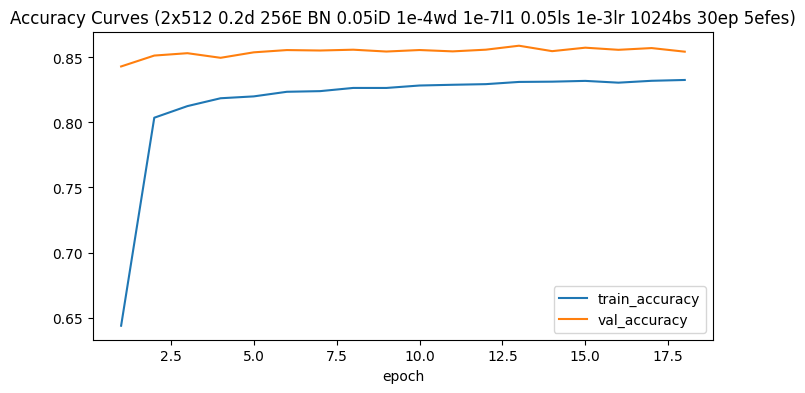

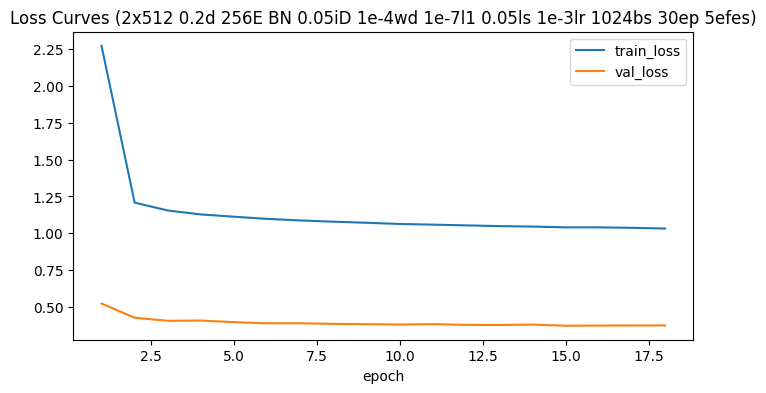

In [21]:
# Figure out the index of the best run according to validation accuracy, 
# get the name of that run, and then find the full run output corresponding to that name 
# so we can look at the training history and other details for that run.
best_run_index = int(results_df["best_val_accuracy"].idxmax())
best_run_name = results_df.loc[best_run_index, "name"]
best_run = next(r for r in run_outputs if r["summary"]["name"] == best_run_name)

best_history_df = pd.DataFrame(best_run["history"])
print("Best run:", best_run_name)

# Plot the training and validation accuracy curves across epochs for the best run, and then do the same for the loss curves.
best_history_df[["epoch", "train_accuracy", "val_accuracy"]].plot(
    x="epoch",
    figsize=(8, 4),
    title=f"Accuracy Curves ({best_run_name})",
)

best_history_df[["epoch", "train_loss", "val_loss"]].plot(
    x="epoch",
    figsize=(8, 4),
    title=f"Loss Curves ({best_run_name})",
)

In [22]:
# Check how fast forward propagation is with the best model by running a load of samples through it and timing how long it takes.
start_time = time.time()
with torch.no_grad():
    for xb, yb in val_loader:
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)
        logits = best_run["model"](xb)
print(f"Finished forward pass through validation set in {time.time() - start_time:.2f} seconds")
# Divide by the number of samples in the validation set to get the average time per sample, and print that out too.
avg_time_per_sample = (time.time() - start_time) / len(val_loader.dataset)
print(f"Average time per sample: {avg_time_per_sample:.6f} seconds")

Finished forward pass through validation set in 0.17 seconds
Average time per sample: 0.000005 seconds


In [ ]:
def evaluate_on_subset(model: nn.Module, X_np: np.ndarray, y_np: np.ndarray) -> Dict[str, float]:
    """
    Evaluates the given model on a subset of the data defined by the provided features and labels numpy arrays,
    computing the average loss, accuracy, and macro-averaged precision for that subset.

    This function is especially useful for evaluating the model on specific slices of the data, such as common vs rare diseases,
    to see if there are differences in performance across these slices. Maybe a model is just really good because it performs well on common
    diseases like the cold by simply guessing that all the time, and thus doesn't really do anything more intelligent than a simple
    greedy strategy that always picks the most common class. By evaluating on the rare disease subset, we can see how well the model is doing on those cases
    where a simple greedy strategy would fail, and thus get a better sense of how much the model is actually learning about the relationships between symptoms 
    and diseases rather than just picking up on class imbalances in the data.

    @param model: The MLP model to evaluate.
    @param X_np: A numpy array of shape (num_samples, num_features) containing the features for the subset of data to evaluate on.
    @param y_np: A numpy array of shape (num_samples,) containing the integer-encoded labels corresponding to the features in X_np.
    @return: A dictionary containing the average loss, accuracy, and macro-averaged precision of the model on the provided subset of data.
     The loss is averaged across all batches, the accuracy is averaged across all batches, 
     and the macro-averaged precision is computed across all predictions and true labels from all batches in the subset.
    """

    # We can delegate to pre-existing helpers for all of this :)
    # See the documentation of the build_loader and evaluate_model functions for details on how they work.
    
    subset_loader = build_loader(X_np, y_np, batch_size=1024, shuffle=False)
    return evaluate_model(model, subset_loader)

# To define what we mean by "common" vs "rare" diseases, we can look at the distribution of disease labels 
# in the training set and pick some cutoff points to define these subsets.
# For the sake of this analysis, I'm just picking the 25th and 75th percentiles as cutoff points, 
# but we could definitely experiment with different ways of defining these subsets.

train_class_counts = pd.Series(y_train).value_counts().sort_values(ascending=False)
common_cutoff = int(train_class_counts.quantile(0.75))
rare_cutoff = int(train_class_counts.quantile(0.25))

common_class_ids = set(train_class_counts[train_class_counts >= common_cutoff].index.tolist())
rare_class_ids = set(train_class_counts[train_class_counts <= rare_cutoff].index.tolist())

common_mask = np.array([label in common_class_ids for label in y_test])
rare_mask = np.array([label in rare_class_ids for label in y_test])

# Now we evalutate every model on the common and rare subsets to see if better overall models also do better on the rare disease subset, 
# or if they are just doing better on the common diseases.
for run in run_outputs:
    # We saved the model and summary for each run in the run_outputs list, 
    # so we can just loop through that rather than retrain from the config data.
    model = run["model"]

    # Metadata about each model is in the summary. Used only to print out the name of the model here.
    # If useful in the future, it has the following structure
    # summary = {
        # "name": cfg.name,
        # "hidden_dims": cfg.hidden_dims,
        # "embedding_dim": cfg.embedding_dim,
        # "dropout": cfg.dropout,
        # "batch_norm": cfg.batch_norm,
        # "input_dropout": cfg.input_dropout,
        # "weight_decay": cfg.weight_decay,
        # "l1_lambda": cfg.l1_lambda,
        # "label_smoothing": cfg.label_smoothing,
        # "max_epochs": cfg.max_epochs,
        # "num_epochs_till_early_stop": cfg.num_epochs_till_early_stop,
        # "best_epoch": run["best_epoch"]["epoch"],
        # "best_val_accuracy": run["best_epoch"]["val_accuracy"],
        # "best_val_macro_precision": run["best_epoch"]["val_macro_precision"],
        # "val_accuracy_final": val_metrics["accuracy"],
        # "val_macro_precision_final": val_metrics["macro_precision"],
        # "test_accuracy": test_metrics["accuracy"],
        # "test_macro_precision": test_metrics["macro_precision"],
    # }

    overall_metrics = evaluate_model(model, test_loader)
    common_metrics = evaluate_on_subset(model, X_test[common_mask], y_test[common_mask])
    rare_metrics = evaluate_on_subset(model, X_test[rare_mask], y_test[rare_mask])

    slice_results = pd.DataFrame(
        [
            {
                "slice": "overall test",
                "n_samples": int(len(y_test)),
                "accuracy": overall_metrics["accuracy"],
                "macro_precision": overall_metrics["macro_precision"],
            },
            {
                "slice": "common disease subset",
                "n_samples": int(common_mask.sum()),
                "accuracy": common_metrics["accuracy"],
                "macro_precision": common_metrics["macro_precision"],
            },
            {
                "slice": "rare disease subset",
                "n_samples": int(rare_mask.sum()),
                "accuracy": rare_metrics["accuracy"],
                "macro_precision": rare_metrics["macro_precision"],
            },
        ]
    )

    # The run summary dictionary is nested under run["summary"], so we read the model name from there.
    titleStr = f"Results for {run['summary']['name']}:"
    print(titleStr)
    print(slice_results)
    print("*" * len(titleStr))


Results for 2x512 0d nE noBN 0iD 0wd 0l1 0ls 1e-3lr 1024bs 30ep 5efes:
                   slice  n_samples  accuracy  macro_precision
0           overall test      37039  0.856475         0.839173
1  common disease subset      24523  0.837436         0.387319
2    rare disease subset        378  0.820106         0.636420
**********************************************************************
Results for 2x512 0.2d nE noBN 0iD 0wd 0l1 0ls 1e-3lr 1024bs 30ep 5efes:
                   slice  n_samples  accuracy  macro_precision
0           overall test      37039  0.860125         0.841385
1  common disease subset      24523  0.840327         0.413290
2    rare disease subset        378  0.785714         0.596593
************************************************************************
Results for 2x512 0.2d nE BN 0.05iD 1e-4wd 0l1 0ls 1e-3lr 1024bs 30ep 5efes:
                   slice  n_samples  accuracy  macro_precision
0           overall test      37039  0.857583         0.857368
1  co